## 1. Setup

In [4]:
# 0. Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
# 1. Load
DATASET = "bank_marketing"
MESSY_DIR = f"../data/messy/{DATASET}"
CONDITIONS = ["clean", "missing_mild", "missing_severe",
              "outlier_mild", "outlier_severe", "noise_mild", "noise_severe"]

dfs = {c: pd.read_csv(f"{MESSY_DIR}/{c}/train.csv") for c in CONDITIONS}
test_df = pd.read_csv(f"../data/processed/{DATASET}/test.csv")

for c, d in dfs.items():
    print(f"{c:<16} shape={d.shape}  missing={d.isnull().mean().mean():.2%}  pos_rate={d['y'].mean():.3f}")
print(f"{'test':<16} shape={test_df.shape}")

clean            shape=(32950, 21)  missing=0.00%  pos_rate=0.113
missing_mild     shape=(32950, 21)  missing=4.76%  pos_rate=0.113
missing_severe   shape=(32950, 21)  missing=9.52%  pos_rate=0.113
outlier_mild     shape=(32950, 21)  missing=0.00%  pos_rate=0.113
outlier_severe   shape=(32950, 21)  missing=0.00%  pos_rate=0.113
noise_mild       shape=(32950, 21)  missing=0.00%  pos_rate=0.150
noise_severe     shape=(32950, 21)  missing=0.00%  pos_rate=0.268
test             shape=(8238, 21)


## 2. EDA

Following the protocol:
1. Basic data loading check (shape, info, columns, describe)
2. Basic descriptive stats (mean, median, std, skew)
3. Missing value profile (% and pattern)
4. Outlier profile (distribution shape, IQR count)
5. Class balance profile (check class balance)
6. Correlation matrix

In [6]:
# 1. Basic data loading (all conditions + test)
all_dfs = {**dfs, "test": test_df}

for name, d in all_dfs.items():
    print(f"\n{'='*70}\n  {name.upper()}\n{'='*70}")
    print(f"Data Shape: {d.shape}")
    print("\nData Info:")
    d.info()
    print("\nData Columns:")
    print(d.columns.tolist())
    print("\nData Description:")
    display(d.describe())


  CLEAN
Data Shape: (32950, 21)

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32950 non-null  int64  
 1   job             32950 non-null  str    
 2   marital         32950 non-null  str    
 3   education       32950 non-null  str    
 4   default         32950 non-null  str    
 5   housing         32950 non-null  str    
 6   loan            32950 non-null  str    
 7   contact         32950 non-null  str    
 8   month           32950 non-null  str    
 9   day_of_week     32950 non-null  str    
 10  duration        32950 non-null  int64  
 11  campaign        32950 non-null  int64  
 12  pdays           32950 non-null  int64  
 13  previous        32950 non-null  int64  
 14  poutcome        32950 non-null  str    
 15  emp.var.rate    32950 non-null  float64
 16  cons.price.idx  32950 non-null  float64
 1

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,40.014112,258.127466,2.560607,962.052413,0.174719,0.080470,93.575881,-40.508489,3.618395,5166.899651,0.112656
std,10.403636,258.975917,2.752326,187.951096,0.499025,1.571266,0.579209,4.628223,1.735896,72.434812,0.316176
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000



  MISSING_MILD
Data Shape: (32950, 21)

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             29655 non-null  float64
 1   job             32950 non-null  str    
 2   marital         32950 non-null  str    
 3   education       32950 non-null  str    
 4   default         32950 non-null  str    
 5   housing         32950 non-null  str    
 6   loan            32950 non-null  str    
 7   contact         32950 non-null  str    
 8   month           32950 non-null  str    
 9   day_of_week     32950 non-null  str    
 10  duration        29655 non-null  float64
 11  campaign        29655 non-null  float64
 12  pdays           29655 non-null  float64
 13  previous        29655 non-null  float64
 14  poutcome        32950 non-null  str    
 15  emp.var.rate    29655 non-null  float64
 16  cons.price.idx  29655 non-null  flo

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,29655.000000,29655.000000,29655.000000,29655.000000,29655.000000,29655.000000,29655.000000,29655.000000,29655.000000,29655.000000,32950.000000
mean,40.042118,257.230282,2.560614,962.099174,0.174406,0.080158,93.575535,-40.504053,3.617739,5166.830214,0.112656
std,10.429778,258.679817,2.750665,187.837362,0.498665,1.570532,0.579069,4.633212,1.736128,72.464582,0.316176
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.000000,179.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,318.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000



  MISSING_SEVERE
Data Shape: (32950, 21)

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             26360 non-null  float64
 1   job             32950 non-null  str    
 2   marital         32950 non-null  str    
 3   education       32950 non-null  str    
 4   default         32950 non-null  str    
 5   housing         32950 non-null  str    
 6   loan            32950 non-null  str    
 7   contact         32950 non-null  str    
 8   month           32950 non-null  str    
 9   day_of_week     32950 non-null  str    
 10  duration        26360 non-null  float64
 11  campaign        26360 non-null  float64
 12  pdays           26360 non-null  float64
 13  previous        26360 non-null  float64
 14  poutcome        32950 non-null  str    
 15  emp.var.rate    26360 non-null  float64
 16  cons.price.idx  26360 non-null  f

...

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,40.014112,258.127466,2.560607,962.052413,0.174719,0.080470,93.575881,-40.508489,3.618395,5166.899651,0.150167
std,10.403636,258.975917,2.752326,187.951096,0.499025,1.571266,0.579209,4.628223,1.735896,72.434812,0.357240
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000



  NOISE_SEVERE
Data Shape: (32950, 21)

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32950 non-null  int64  
 1   job             32950 non-null  str    
 2   marital         32950 non-null  str    
 3   education       32950 non-null  str    
 4   default         32950 non-null  str    
 5   housing         32950 non-null  str    
 6   loan            32950 non-null  str    
 7   contact         32950 non-null  str    
 8   month           32950 non-null  str    
 9   day_of_week     32950 non-null  str    
 10  duration        32950 non-null  int64  
 11  campaign        32950 non-null  int64  
 12  pdays           32950 non-null  int64  
 13  previous        32950 non-null  int64  
 14  poutcome        32950 non-null  str    
 15  emp.var.rate    32950 non-null  float64
 16  cons.price.idx  32950 non-null  flo

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,40.014112,258.127466,2.560607,962.052413,0.174719,0.080470,93.575881,-40.508489,3.618395,5166.899651,0.267557
std,10.403636,258.975917,2.752326,187.951096,0.499025,1.571266,0.579209,4.628223,1.735896,72.434812,0.442692
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,1.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000



  TEST
Data Shape: (8238, 21)

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 8238 entries, 0 to 8237
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             8238 non-null   int64  
 1   job             8238 non-null   str    
 2   marital         8238 non-null   str    
 3   education       8238 non-null   str    
 4   default         8238 non-null   str    
 5   housing         8238 non-null   str    
 6   loan            8238 non-null   str    
 7   contact         8238 non-null   str    
 8   month           8238 non-null   str    
 9   day_of_week     8238 non-null   str    
 10  duration        8238 non-null   int64  
 11  campaign        8238 non-null   int64  
 12  pdays           8238 non-null   int64  
 13  previous        8238 non-null   int64  
 14  poutcome        8238 non-null   str    
 15  emp.var.rate    8238 non-null   float64
 16  cons.price.idx  8238 non-null   float64
 17  c

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000
mean,40.063850,258.915149,2.595533,964.167516,0.165938,0.087546,93.574797,-40.479048,3.632872,5167.580918,0.112649
std,10.491945,260.503791,2.839657,182.692620,0.478018,1.569816,0.577398,4.628302,1.728697,71.515506,0.316182
min,17.000000,3.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,101.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.000000,178.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.000000,3631.000000,41.000000,999.000000,5.000000,1.400000,94.767000,-26.900000,5.000000,5228.100000,1.000000


In [9]:
# 2. Basic descriptive stats (mean, median, std, skew)
print(f"Mean:")
print(df.mean(numeric_only=True))
print(f"\nMedian:")
print(df.median(numeric_only=True))
print(f"\nStandard Deviation:")
print(df.std(numeric_only=True))
print(f"\nSkew:")
print(df.skew(numeric_only=True))

Mean:
age                 40.024060
duration           258.285010
campaign             2.567593
pdays              962.475454
previous             0.172963
emp.var.rate         0.081886
cons.price.idx      93.575664
cons.conf.idx      -40.502600
euribor3m            3.621291
nr.employed       5167.035911
dtype: float64

Median:
age                 38.000
duration           180.000
campaign             2.000
pdays              999.000
previous             0.000
emp.var.rate         1.100
cons.price.idx      93.749
cons.conf.idx      -41.800
euribor3m            4.857
nr.employed       5191.000
dtype: float64

Standard Deviation:
age                10.421250
duration          259.279249
campaign            2.770014
pdays             186.910907
previous            0.494901
emp.var.rate        1.570960
cons.price.idx      0.578840
cons.conf.idx       4.628198
euribor3m           1.734447
nr.employed        72.251528
dtype: float64

Skew:
age               0.784697
duration          3.26314

In [7]:
# 3. Missing value profile (% per column, all conditions)
missing_pct = pd.DataFrame(
    {name: d.isnull().mean() * 100 for name, d in all_dfs.items()}
).round(2)

print("Missing Value in % (per column, per condition):")
print(missing_pct.to_string())

print("\nOverall missing % per condition:")
print(missing_pct.mean().round(2).to_string())

Missing Value in % (per column, per condition):
                clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe  test
age               0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
job               0.0           0.0             0.0           0.0             0.0         0.0           0.0   0.0
marital           0.0           0.0             0.0           0.0             0.0         0.0           0.0   0.0
education         0.0           0.0             0.0           0.0             0.0         0.0           0.0   0.0
default           0.0           0.0             0.0           0.0             0.0         0.0           0.0   0.0
housing           0.0           0.0             0.0           0.0             0.0         0.0           0.0   0.0
loan              0.0           0.0             0.0           0.0             0.0         0.0           0.0   0.0
contact           0.0           0.0     

In [8]:
# 4. Outlier profile (distribution shape, IQR count)
num_cols = [c for c in all_dfs["clean"].select_dtypes(include="number").columns if c != "y"]

def iqr_outlier_pct(d, cols):
    out = {}
    for c in cols:
        q1, q3 = d[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out[c] = ((d[c] < lo) | (d[c] > hi)).mean() * 100
    return pd.Series(out)

outlier_pct = pd.DataFrame(
    {name: iqr_outlier_pct(d, num_cols) for name, d in all_dfs.items()}
).round(2)

print("IQR outlier % (per column, per condition):")
print(outlier_pct.to_string())

skew = pd.DataFrame(
    {name: d[num_cols].skew() for name, d in all_dfs.items()}
).round(2)

print("\nSkewness (per column, per condition):")
print(skew.to_string())

IQR outlier % (per column, per condition):
                clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
age              1.12          1.04            0.84          5.07            7.49        1.12          1.12   1.23
duration         7.18          6.44            5.82         11.09           19.00        7.18          7.18   7.33
campaign         5.81          5.26            4.57         10.54           19.98        5.81          5.81   5.95
pdays            3.72          3.34            2.92          8.55           18.10        3.72          3.72   3.51
previous        13.76         12.36           11.03         18.05           15.65       13.76         13.76  13.24
emp.var.rate     0.00          0.00            0.00          0.27            0.76        0.00          0.00   0.00
cons.price.idx   0.00          0.00            0.00          4.09            6.47        0.00          0.00   0.00
cons.conf.idx    1.09          0.97  

In [9]:
# Ground-truth injection rate + range check
for cond in ["outlier_mild", "outlier_severe"]:
    d = all_dfs[cond]
    changed = (d[num_cols] != all_dfs["clean"][num_cols]).mean() * 100
    summary = pd.DataFrame({
        "changed_%": changed.round(2),
        "clean_min": all_dfs["clean"][num_cols].min(),
        "clean_max": all_dfs["clean"][num_cols].max(),
        f"{cond}_min": d[num_cols].min(),
        f"{cond}_max": d[num_cols].max(),
        "clean_std": all_dfs["clean"][num_cols].std().round(2),
        f"{cond}_std": d[num_cols].std().round(2),
    })
    print(f"\n{cond.upper()}")
    print(summary.to_string())


OUTLIER_MILD
                changed_%  clean_min  clean_max  outlier_mild_min  outlier_mild_max  clean_std  outlier_mild_std
age                  5.00     17.000     98.000         -1.000000         98.000000      10.40             12.99
duration             5.00      0.000   4918.000       -777.000000       4918.000000     258.98            325.15
campaign             4.99      1.000     56.000         -8.000000         56.000000       2.75              3.36
pdays                5.00      0.000    999.000          0.000000       1713.000000     187.95            235.48
previous             5.00      0.000      7.000          0.000000          8.000000       0.50              1.77
emp.var.rate         5.00     -3.400      1.400         -6.202063          6.363258       1.57              1.97
cons.price.idx       5.00     92.201     94.767         91.259132         95.892065       0.58              0.73
cons.conf.idx        5.00    -50.800    -26.900        -59.013293        -22.00511

In [10]:
# 5. Class balance profile (check class balance)
balance = pd.DataFrame(
    {name: d["y"].value_counts(normalize=True).sort_index() * 100 for name, d in all_dfs.items()}
).round(2)

print("Class balance % (y=0 / y=1):")
print(balance.to_string())

Class balance % (y=0 / y=1):
   clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
y                                                                                                    
0  88.73         88.73           88.73         88.73           88.73       84.98         73.24  88.74
1  11.27         11.27           11.27         11.27           11.27       15.02         26.76  11.26


In [11]:
# 5b. Direct label noise check (ground truth vs clean)
clean_y = all_dfs["clean"]["y"]

for cond in ["noise_mild", "noise_severe"]:
    noisy_y = all_dfs[cond]["y"]
    flipped = noisy_y != clean_y
    print(f"\n{cond.upper()}")
    print(f"  Overall flip rate : {flipped.mean():.2%}")
    print(f"  Flipped 0 → 1     : {((clean_y == 0) & flipped).sum():,} "
          f"({flipped[clean_y == 0].mean():.2%} of class 0)")
    print(f"  Flipped 1 → 0     : {((clean_y == 1) & flipped).sum():,} "
          f"({flipped[clean_y == 1].mean():.2%} of class 1)")


NOISE_MILD
  Overall flip rate : 5.00%
  Flipped 0 → 1     : 1,442 (4.93% of class 0)
  Flipped 1 → 0     : 206 (5.55% of class 1)

NOISE_SEVERE
  Overall flip rate : 20.00%
  Flipped 0 → 1     : 5,847 (20.00% of class 0)
  Flipped 1 → 0     : 743 (20.02% of class 1)


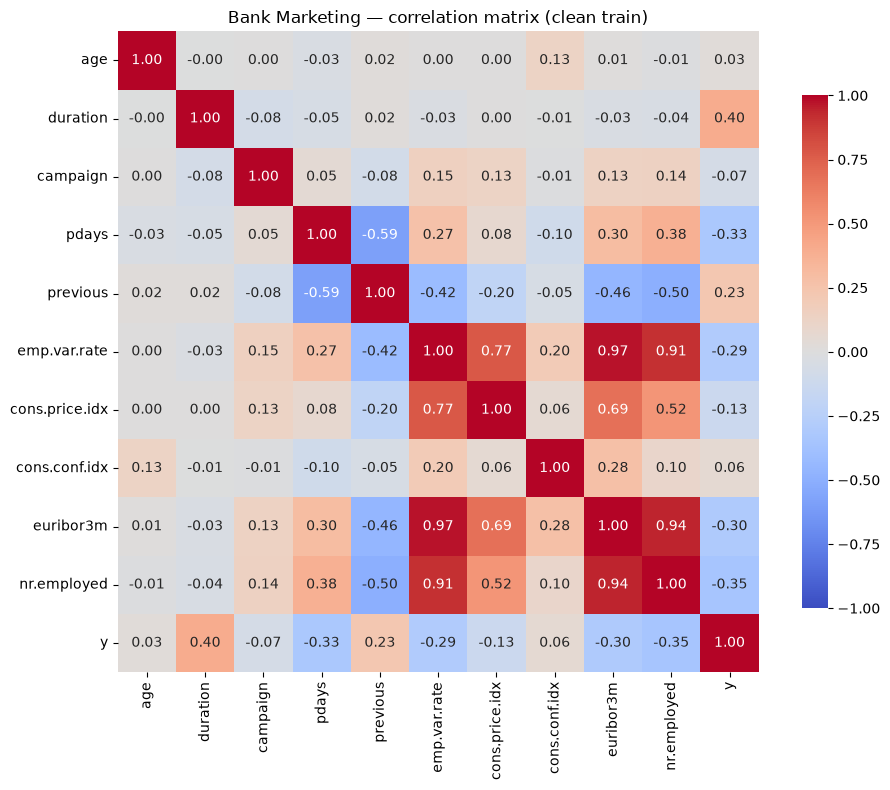

Correlation with y (per condition):
                clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
age             0.029         0.029           0.034         0.026           0.010       0.021         0.012  0.037
duration        0.401         0.404           0.408         0.311           0.211       0.320         0.170  0.423
campaign       -0.065        -0.067          -0.070        -0.047          -0.035      -0.046        -0.025 -0.070
pdays          -0.326        -0.324          -0.322        -0.248          -0.162      -0.258        -0.136 -0.322
previous        0.230         0.226           0.223         0.062           0.038       0.177         0.100  0.232
emp.var.rate   -0.294        -0.289          -0.294        -0.226          -0.154      -0.226        -0.124 -0.317
cons.price.idx -0.133        -0.126          -0.131        -0.099          -0.066      -0.102        -0.059 -0.151
cons.conf.idx   0.055         0.049         

: 

In [ ]:
# 6. Correlation matrix
corr_cols = num_cols + ["y"]

# 6a. Full heatmap — clean baseline
corr_clean = all_dfs["clean"][corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title("Bank Marketing — correlation matrix (clean train)")
plt.tight_layout()
plt.show()

# 6b. Correlation with target, per condition
target_corr = pd.DataFrame(
    {name: d[corr_cols].corr()["y"].drop("y") for name, d in all_dfs.items()}
).round(3)

print("Correlation with y (per condition):")
print(target_corr.to_string())

# 6c. How much each condition distorts the whole matrix vs clean
distortion = pd.Series(
    {name: (d[corr_cols].corr() - corr_clean).abs().values.mean() for name, d in all_dfs.items()}
).round(4)

print("\nMean absolute change in correlation vs clean:")
print(distortion.to_string())